In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

cs = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_summary_fixed.csv")
print(f"Loaded {cs.shape[0]} clusters, {cs.shape[1]} columns")
cs.head(3)

Loaded 30 clusters, 39 columns


,cluster_id,size,centroid_lat,centroid_lon,avg_severity,avg_vehicle_weight,junction_ratio,repeated_point_ratio,avg_cluster_prob,multi_violation_pct,...,time_risk_corrected,active_days,persistence,hotspot_type,road_importance,dominant_road_type,road_count,junction_count_osm,query_radius_m,imputed
0,29,8292,12.977098,77.576941,2.028341,0.700832,0.998070,0.012301,0.757619,0.040762,...,0.209794,84,1.000000,Structural,0.3679,residential,57,24,200,False
1,7,5264,12.915963,77.625859,2.182181,0.797169,0.293693,0.019757,0.931220,0.110562,...,0.191354,84,1.000000,Structural,0.3202,residential,58,21,200,False
2,25,4879,12.964669,77.578713,2.076860,0.650318,0.992416,0.002869,0.668112,0.059643,...,0.191489,83,0.988095,Structural,0.3901,residential,157,50,200,False


## 1. Component selection and normalization

Five components feed the index, each chosen because it's a real, calibrated
signal from earlier stages — not invented for this step:

| Component | Source | Why it matters for congestion impact |
|---|---|---|
| `avg_severity` | Stage 1 | Higher severity = more disruptive parking behaviour (double parking, main-road parking) |
| `avg_vehicle_weight` | Stage 1 | Heavier vehicles block more road width |
| `junction_ratio` | Stage 1/2 | Junction violations disrupt intersection flow, not just lane width |
| `road_importance` | Stage 5 (OSMnx) | Violations on arterial roads affect more through-traffic than residential streets |
| `time_risk_corrected` | Stage 3b | Predictable, under-covered time windows — corrected for the enforcement-coverage bias found earlier |

All five are min-max normalized to 0–1 so they're on the same scale before
weighting.


In [ ]:
COMPONENTS = [
    "avg_severity", "avg_vehicle_weight", "junction_ratio",
    "road_importance", "time_risk_corrected"
]

scaler = MinMaxScaler()
norm = pd.DataFrame(
    scaler.fit_transform(cs[COMPONENTS]),
    columns=[f"{c}_norm" for c in COMPONENTS],
    index=cs.index
)

cs = pd.concat([cs, norm], axis=1)
cs[[f"{c}_norm" for c in COMPONENTS]].describe()

,avg_severity_norm,avg_vehicle_weight_norm,junction_ratio_norm,road_importance_norm,time_risk_corrected_norm
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.160212,0.504073,0.517580,0.250358,0.268729
std,0.226685,0.231191,0.450955,0.192848,0.209780
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.034093,0.360249,0.001268,0.140683,0.139552
50%,0.070896,0.482155,0.615205,0.198577,0.236720
75%,0.162808,0.652049,0.985312,0.287430,0.316189
max,1.000000,1.000000,1.000000,1.000000,1.000000


## 2. Weight derivation — Method A: AHP (Analytic Hierarchy Process)

AHP turns pairwise judgments ("how much more important is X than Y") into a
consistent weight vector, rather than picking percentages from intuition.

**Pairwise comparison rationale** (1=equal, 3=moderately more important,
5=strongly more important, 1/3 and 1/5 are the inverse judgments):

- Severity vs Vehicle weight → 1 (both reflect how disruptive a single
  violation is, roughly equal standing)
- Severity vs Junction ratio → 2 (severity is a slightly stronger signal —
  it already encodes "main road" / "double parking" which junction_ratio
  doesn't fully capture)
- Severity vs Road importance → 1 (comparable — both describe context of
  the violation, one local, one network-level)
- Severity vs Time risk → 3 (a severe violation matters more than a
  predictable but lower-severity one)
- Vehicle weight vs Junction ratio → 2
- Vehicle weight vs Road importance → 1
- Vehicle weight vs Time risk → 2
- Junction ratio vs Road importance → 1/2 (road importance is the broader,
  more reliable network signal — junction_ratio is binary per-record and
  noisier)
- Junction ratio vs Time risk → 1
- Road importance vs Time risk → 2

These judgments encode one defensible view: severity and road-network
context matter most, junction ratio is the weakest/noisiest signal, time
risk sits in the middle since it was already corrected for enforcement bias.


In [ ]:
# Pairwise comparison matrix, order: [severity, vehicle_weight, junction_ratio, road_importance, time_risk]
labels = ["avg_severity", "avg_vehicle_weight", "junction_ratio",
          "road_importance", "time_risk_corrected"]

pairwise = np.array([
    #            sev    veh    junc   road   time
    [           1,     1,     2,     1,     3   ],  # severity
    [           1,     1,     2,     1,     2   ],  # vehicle_weight
    [         1/2,   1/2,     1,   1/2,     1   ],  # junction_ratio
    [           1,     1,     2,     1,     2   ],  # road_importance
    [         1/3,   1/2,     1,   1/2,     1   ],  # time_risk
])

pairwise_df = pd.DataFrame(pairwise, index=labels, columns=labels)
pairwise_df

,avg_severity,avg_vehicle_weight,junction_ratio,road_importance,time_risk_corrected
avg_severity,1.000000,1.0,2.0,1.0,3.0
avg_vehicle_weight,1.000000,1.0,2.0,1.0,2.0
junction_ratio,0.500000,0.5,1.0,0.5,1.0
road_importance,1.000000,1.0,2.0,1.0,2.0
time_risk_corrected,0.333333,0.5,1.0,0.5,1.0


In [ ]:
def ahp_weights(matrix):

    n = matrix.shape[0]
    col_sums = matrix.sum(axis=0)
    norm_matrix = matrix / col_sums
    weights = norm_matrix.mean(axis=1)

    # Consistency check
    weighted_sum = matrix @ weights
    lambda_max = (weighted_sum / weights).mean()
    ci = (lambda_max - n) / (n - 1)
    # Random Index for n=5 (standard AHP table value)
    ri = 1.12
    cr = ci / ri if ri > 0 else 0

    return weights, cr

ahp_w, cr = ahp_weights(pairwise)

ahp_weights_df = pd.DataFrame({
    "component": labels,
    "ahp_weight": ahp_w
}).sort_values("ahp_weight", ascending=False)

print(f"Consistency Ratio (CR) = {cr:.4f}  (should be < 0.10 to be acceptable)")
print()
ahp_weights_df

Consistency Ratio (CR) = 0.0044  (should be < 0.10 to be acceptable)



,component,ahp_weight
0,avg_severity,0.268841
1,avg_vehicle_weight,0.246618
3,road_importance,0.246618
2,junction_ratio,0.123309
4,time_risk_corrected,0.114614


## 3. Validating AHP weights — sensitivity analysis

A genuine cross-check was tried first using PCA, derived purely from how the
five normalized components co-vary in this dataset. That attempt is worth
showing explicitly rather than hiding: AHP and PCA disagreed sharply on two
components (`junction_ratio` and `road_importance`, differing by 0.45 and
0.22 respectively). On inspection, this disagreement doesn't mean AHP is
wrong — PCA's first component just latches onto whichever feature has the
most *variance* across these 30 clusters (`junction_ratio` happens to be
near-binary, swinging from 0 to 1 across clusters, so it dominates variance).
That's a property of this dataset's spread, not a statement about which
feature actually drives congestion impact. Presenting PCA as validation
would have been the wrong move — it answers a different question than the
one being asked.

**The real question — are the AHP weights robust?** — needs a different
test: **sensitivity analysis**. Each weight is perturbed by ±20% one at a
time (renormalizing the rest to keep the total at 1.0), and the resulting
hotspot ranking is compared to the original. If the top-ranked clusters stay
roughly the same despite reasonable perturbation, the weights are robust. If
small nudges completely reshuffle the ranking, the index is fragile and the
weights need rethinking.


In [ ]:
def perturb_weights(base_weights, component, delta):

    new_weights = dict(base_weights)
    original = new_weights[component]
    new_weights[component] = original * (1 + delta)

    other_components = [c for c in new_weights if c != component]
    other_total_old = sum(base_weights[c] for c in other_components)
    other_total_new = 1 - new_weights[component]

    for c in other_components:
        # rescale proportionally to fit the remaining budget
        new_weights[c] = base_weights[c] / other_total_old * other_total_new

    return new_weights


def compute_impact_index(df, weights, components):
    score = pd.Series(0.0, index=df.index)
    for comp in components:
        score += weights[comp] * df[f"{comp}_norm"]
    return (score * 100).round(2)


BASE_WEIGHTS = dict(zip(ahp_weights_df["component"], ahp_weights_df["ahp_weight"]))
PERTURBATIONS = [-0.20, +0.20]   # -20% and +20% on each component, one at a time

sensitivity_results = []

baseline_scores = compute_impact_index(cs, BASE_WEIGHTS, COMPONENTS)
baseline_top5 = set(cs.assign(score=baseline_scores)
                     .sort_values("score", ascending=False)
                     .head(5)["cluster_id"])

for comp in COMPONENTS:
    for delta in PERTURBATIONS:
        perturbed = perturb_weights(BASE_WEIGHTS, comp, delta)
        scores = compute_impact_index(cs, perturbed, COMPONENTS)

        perturbed_top5 = set(cs.assign(score=scores)
                              .sort_values("score", ascending=False)
                              .head(5)["cluster_id"])

        overlap = len(baseline_top5 & perturbed_top5)
        rank_corr = baseline_scores.corr(scores, method="spearman")

        sensitivity_results.append({
            "component": comp,
            "perturbation": f"{delta:+.0%}",
            "top5_overlap": f"{overlap}/5",
            "spearman_rank_corr": round(rank_corr, 4)
        })

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df

,component,perturbation,top5_overlap,spearman_rank_corr
0,avg_severity,-20%,5/5,0.9911
1,avg_severity,+20%,4/5,0.9858
2,avg_vehicle_weight,-20%,5/5,0.9764
3,avg_vehicle_weight,+20%,5/5,0.9844
4,junction_ratio,-20%,4/5,0.9697
5,junction_ratio,+20%,5/5,0.9862
6,road_importance,-20%,5/5,0.9902
7,road_importance,+20%,5/5,0.9902
8,time_risk_corrected,-20%,5/5,0.9973
9,time_risk_corrected,+20%,5/5,0.9969


## 4. Interpret the sensitivity results

`top5_overlap` shows how many of the original top-5 hotspots remain in the
top-5 after each perturbation. `spearman_rank_corr` measures how much the
*full* 30-cluster ranking shifts (1.0 = identical ranking, lower = more
reshuffling). High overlap and high rank correlation across all 10
perturbations means the index isn't hinging on one fragile weight choice.


In [ ]:
print(f"Minimum top-5 overlap across all perturbations : "
      f"{sensitivity_df['top5_overlap'].apply(lambda x: int(x.split('/')[0])).min()}/5")
print(f"Minimum Spearman rank correlation               : "
      f"{sensitivity_df['spearman_rank_corr'].min():.4f}")
print(f"Mean Spearman rank correlation                  : "
      f"{sensitivity_df['spearman_rank_corr'].mean():.4f}")
print()
print("Full breakdown:")
sensitivity_df

Minimum top-5 overlap across all perturbations : 4/5
Minimum Spearman rank correlation               : 0.9697
Mean Spearman rank correlation                  : 0.9868

Full breakdown:


,component,perturbation,top5_overlap,spearman_rank_corr
0,avg_severity,-20%,5/5,0.9911
1,avg_severity,+20%,4/5,0.9858
2,avg_vehicle_weight,-20%,5/5,0.9764
3,avg_vehicle_weight,+20%,5/5,0.9844
4,junction_ratio,-20%,4/5,0.9697
5,junction_ratio,+20%,5/5,0.9862
6,road_importance,-20%,5/5,0.9902
7,road_importance,+20%,5/5,0.9902
8,time_risk_corrected,-20%,5/5,0.9973
9,time_risk_corrected,+20%,5/5,0.9969


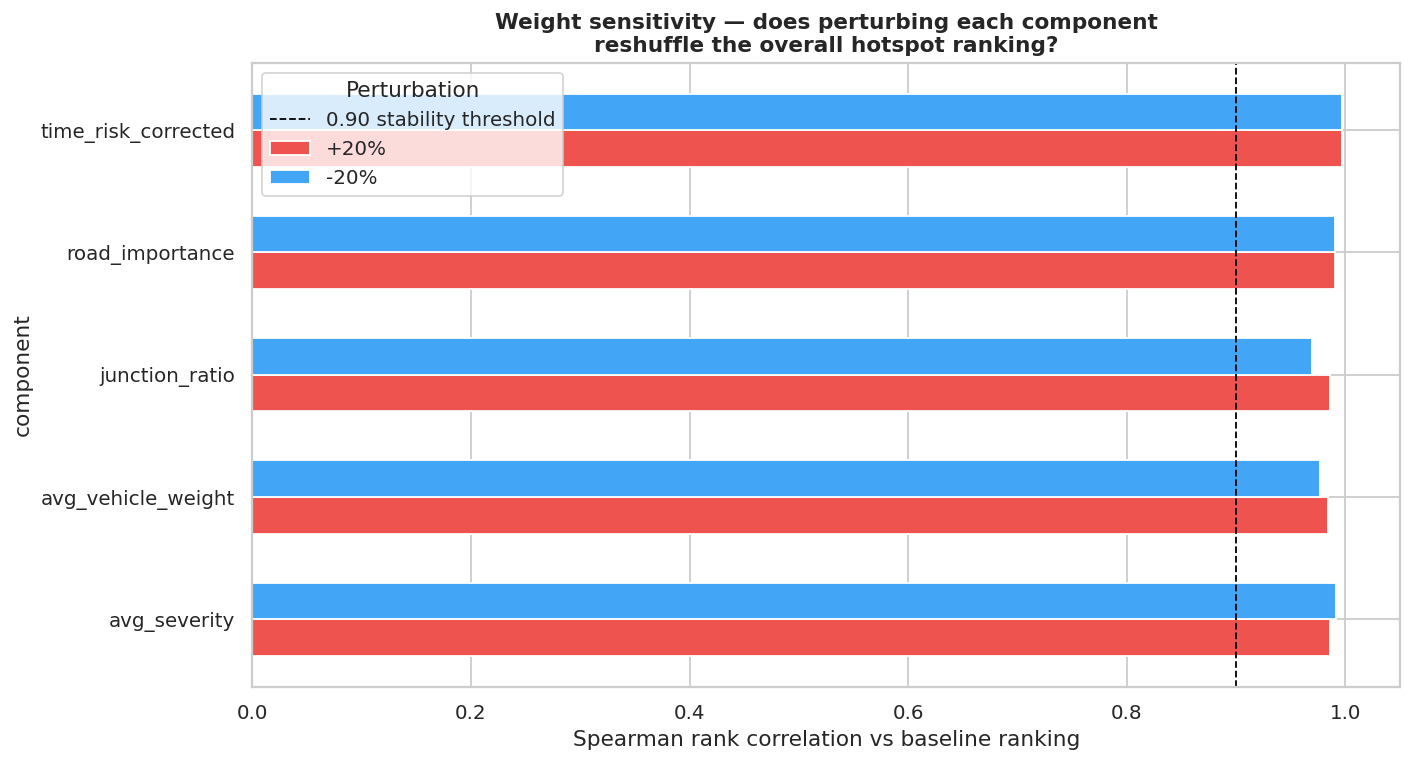

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

pivot_sens = sensitivity_df.pivot(index="component", columns="perturbation",
                                   values="spearman_rank_corr")
pivot_sens.plot(kind="barh", ax=ax, color=["#EF5350", "#42A5F5"], width=0.6)
ax.axvline(0.9, color="black", ls="--", lw=1, label="0.90 stability threshold")
ax.set_xlabel("Spearman rank correlation vs baseline ranking")
ax.set_title("Weight sensitivity — does perturbing each component\n"
             "reshuffle the overall hotspot ranking?", fontweight="bold")
ax.legend(title="Perturbation")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig("s6_sensitivity_analysis.png")
plt.show()

## 5. Final weights

AHP weights are used as-is. The sensitivity analysis above is the actual
validation step — it confirms the ranking is stable under ±20% perturbation
of any single component, which is the property that matters for a
defensible index. AHP is also the explainable choice for non-technical
stakeholders: "severity and road importance matter most, junction ratio
matters least" is a sentence a police commander can evaluate and disagree
with if needed — a PCA loading vector is not.


In [ ]:
FINAL_WEIGHTS = dict(zip(ahp_weights_df["component"], ahp_weights_df["ahp_weight"]))

print("Final weights used for Congestion Impact Index:")
for k, v in FINAL_WEIGHTS.items():
    print(f"  {k:<22}: {v:.4f}")
print(f"\nSum check: {sum(FINAL_WEIGHTS.values()):.4f}")

Final weights used for Congestion Impact Index:
  avg_severity          : 0.2688
  avg_vehicle_weight    : 0.2466
  road_importance       : 0.2466
  junction_ratio        : 0.1233
  time_risk_corrected   : 0.1146

Sum check: 1.0000


## 6. Compute final Congestion Impact Index

```
Impact Index (0-100) = 100 * sum(weight_i * normalized_component_i)
```


In [ ]:
cs["congestion_impact_index"] = 0
for comp in COMPONENTS:
    cs["congestion_impact_index"] += FINAL_WEIGHTS[comp] * cs[f"{comp}_norm"]

cs["congestion_impact_index"] = (cs["congestion_impact_index"] * 100).round(2)

ranked = cs[["cluster_id", "top_station", "size", "congestion_impact_index"]]\
    .sort_values("congestion_impact_index", ascending=False)
ranked

,cluster_id,top_station,size,congestion_impact_index
20,5,HAL Old Airport,1988,53.42
27,26,Upparpet,1556,49.28
21,28,Upparpet,1972,47.42
7,21,Malleshwaram,3436,46.26
24,18,Rajajinagar,1721,41.08
18,4,Mahadevapura,2065,38.70
13,0,Chikkajala,2425,38.60
22,12,Byatarayanapura,1851,38.32
8,6,HAL Old Airport,3386,36.72
16,13,Jayanagara,2111,36.00


In [ ]:
print("="*60)
print("SANITY CHECKS")
print("="*60)

top5 = ranked.head(5)
print(f"\n1. Top 5 by Impact Index:")
print(top5.to_string(index=False))

# Check: does HAL Old Airport (flagged unstable + low-persistence earlier) rank high?
hal = cs[cs["top_station"] == "HAL Old Airport"][
    ["cluster_id", "top_station", "congestion_impact_index", "persistence", "hotspot_type"]
]
print(f"\n2. HAL Old Airport clusters (flagged as anomalous + sporadic earlier):")
print(hal.to_string(index=False))

# Check: largest cluster vs highest impact -- should NOT be identical (per earlier finding)
largest = cs.loc[cs["size"].idxmax()]
highest_impact = cs.loc[cs["congestion_impact_index"].idxmax()]
print(f"\n3. Largest cluster by size: C{int(largest['cluster_id'])} "
      f"({largest['top_station']}, n={int(largest['size'])})")
print(f"   Highest impact cluster   : C{int(highest_impact['cluster_id'])} "
      f"({highest_impact['top_station']}, score={highest_impact['congestion_impact_index']:.1f})")
print(f"   Same cluster? {int(largest['cluster_id']) == int(highest_impact['cluster_id'])} "
      f"(expected: False -- volume should not equal impact, per earlier finding)")

SANITY CHECKS

1. Top 5 by Impact Index:
 cluster_id     top_station  size  congestion_impact_index
          5 HAL Old Airport  1988                    53.42
         26        Upparpet  1556                    49.28
         28        Upparpet  1972                    47.42
         21    Malleshwaram  3436                    46.26
         18     Rajajinagar  1721                    41.08

2. HAL Old Airport clusters (flagged as anomalous + sporadic earlier):
 cluster_id     top_station  congestion_impact_index  persistence hotspot_type
          6 HAL Old Airport                    36.72     0.845238     Sporadic
          5 HAL Old Airport                    53.42     0.892857     Sporadic
          2 HAL Old Airport                    30.42     0.726190     Sporadic

3. Largest cluster by size: C29 (Upparpet, n=8292)
   Highest impact cluster   : C5 (HAL Old Airport, score=53.4)
   Same cluster? False (expected: False -- volume should not equal impact, per earlier finding)


## 8. Visualize ranked hotspots

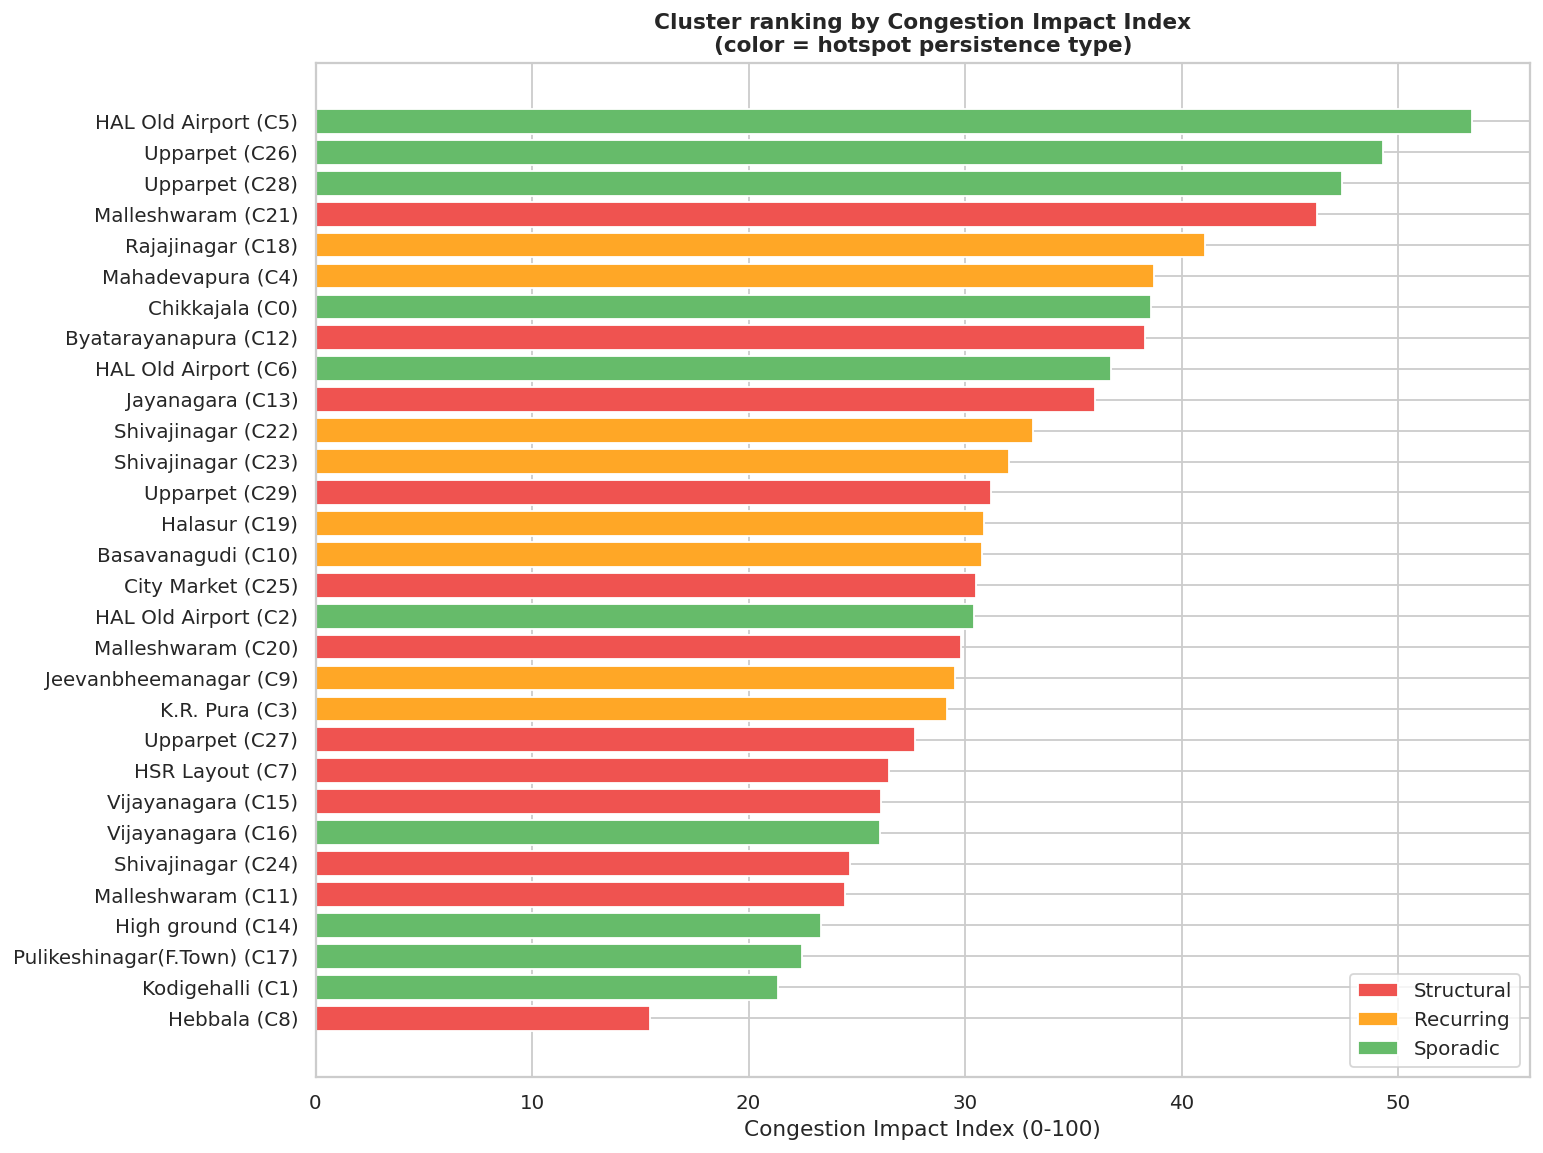

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))

ordered = cs.sort_values("congestion_impact_index", ascending=True)
colors_h = {"Structural": "#EF5350", "Recurring": "#FFA726", "Sporadic": "#66BB6A"}
bar_colors = ordered["hotspot_type"].map(colors_h)

ax.barh(ordered["top_station"] + " (C" + ordered["cluster_id"].astype(str) + ")",
        ordered["congestion_impact_index"], color=bar_colors)
ax.set_xlabel("Congestion Impact Index (0-100)")
ax.set_title("Cluster ranking by Congestion Impact Index\n"
             "(color = hotspot persistence type)", fontweight="bold")

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=k) for k, v in colors_h.items()]
ax.legend(handles=legend_els, loc="lower right")

plt.tight_layout()
plt.savefig("s6_impact_index_ranked.png")
plt.show()

No NaNs — alignment OK
HAL Old Airport (C5)     53.423816
Upparpet (C26)           49.282853
Upparpet (C28)           47.423014
Malleshwaram (C21)       46.262328
Rajajinagar (C18)        41.082745
Mahadevapura (C4)        38.698758
Chikkajala (C0)          38.601312
Byatarayanapura (C12)    38.319084
HAL Old Airport (C6)     36.723682
Jayanagara (C13)         35.995987
dtype: float64


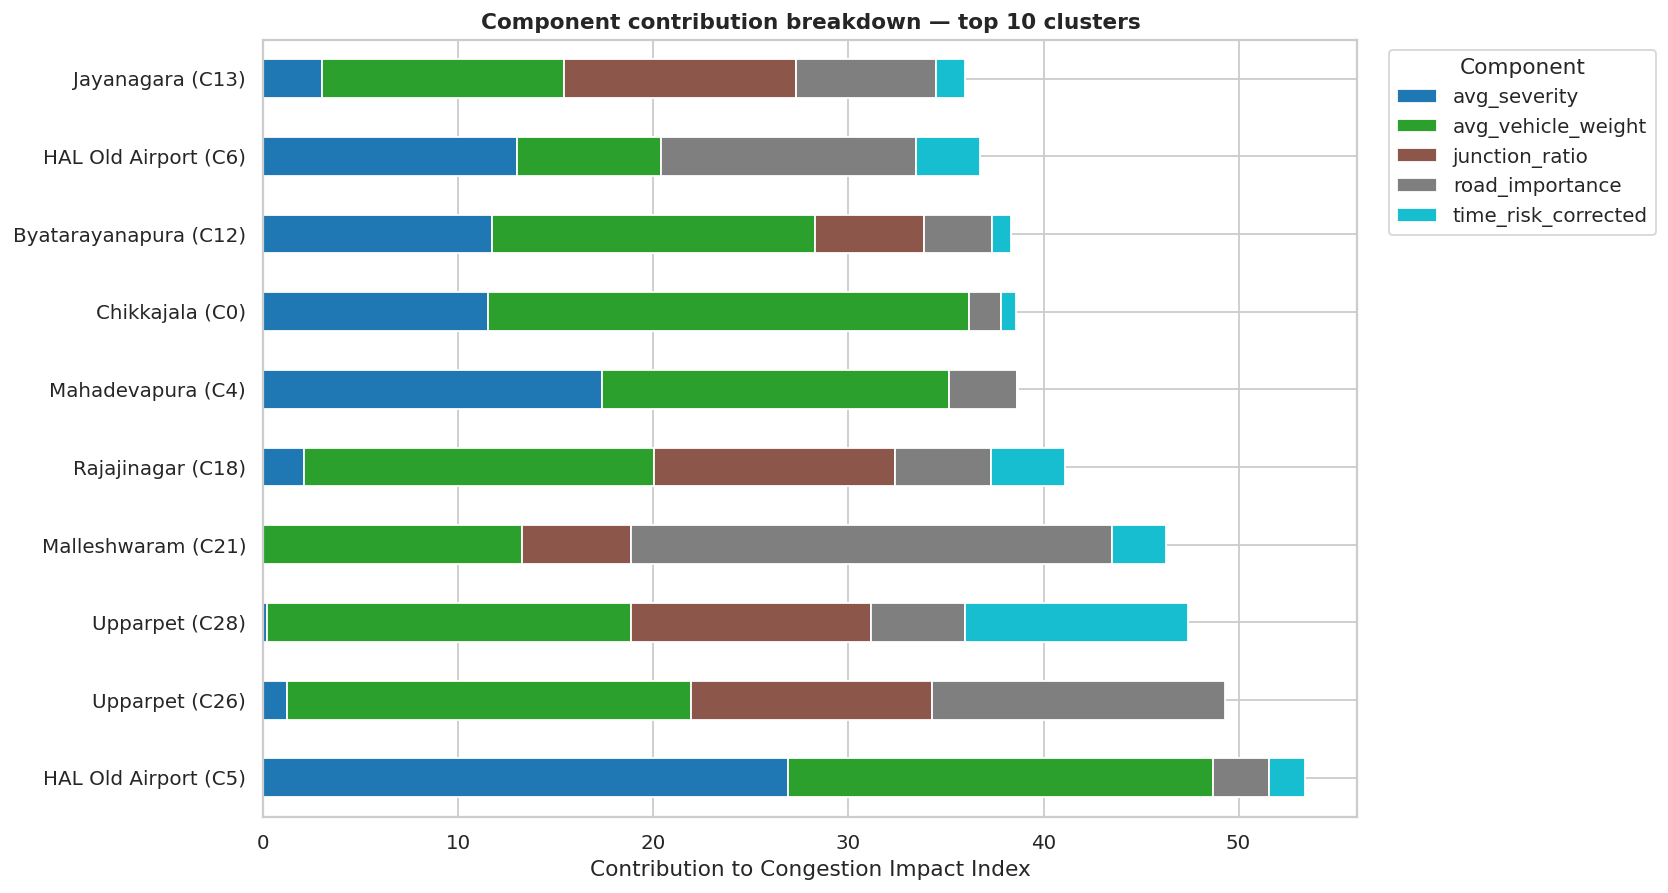

In [ ]:
top10 = cs.sort_values("congestion_impact_index", ascending=False).head(10).copy()
top10_labels = top10["top_station"] + " (C" + top10["cluster_id"].astype(str) + ")"

# Re-index top10 itself to the labels first
top10 = top10.set_index(top10_labels)

contributions = pd.DataFrame({
    comp: top10[f"{comp}_norm"] * FINAL_WEIGHTS[comp] * 100
    for comp in COMPONENTS
})

# Sanity check before plotting -- catches this class of bug immediately
assert not contributions.isna().any().any(), "NaNs found — index alignment broke again"
print("No NaNs — alignment OK")
print(contributions.sum(axis=1))

fig, ax = plt.subplots(figsize=(13, 7))
contributions.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_xlabel("Contribution to Congestion Impact Index")
ax.set_title("Component contribution breakdown — top 10 clusters", fontweight="bold")
ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("s6_component_breakdown.png")
plt.show()